Loading data...


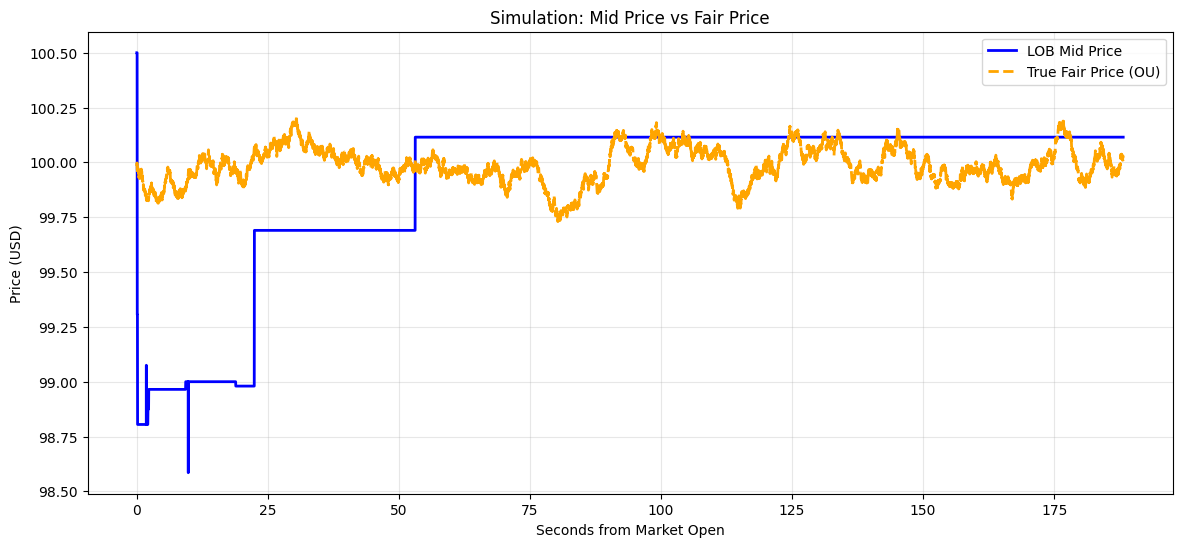

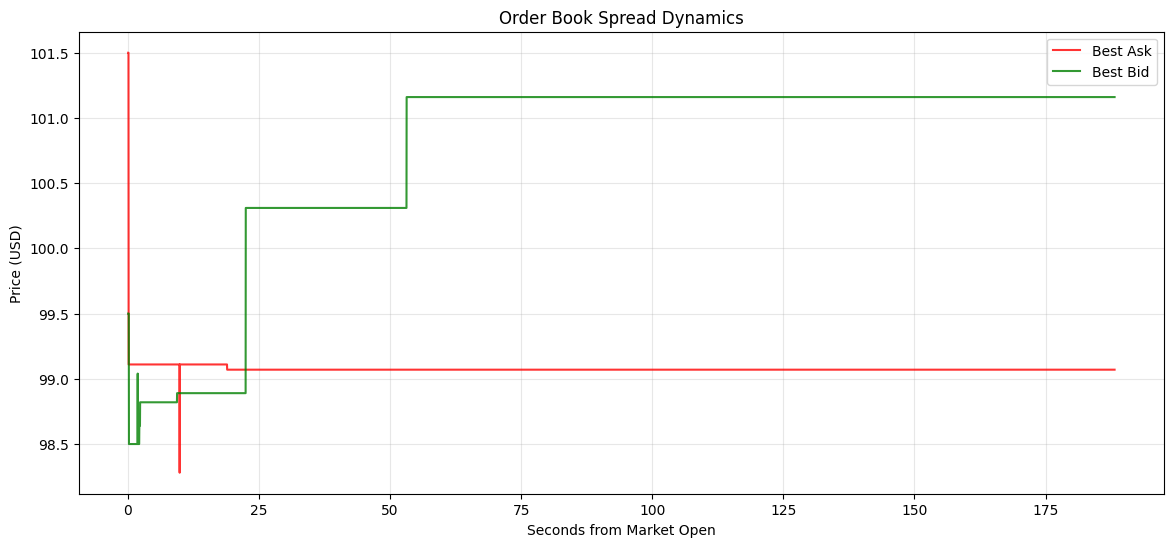

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
print("Loading data...")
df_market = pd.read_csv('sim_market.csv')

# Convert nanoseconds to seconds from market open for readability
start_time = df_market['sim_time_ns'].iloc[0]
df_market['time_sec'] = (df_market['sim_time_ns'] - start_time) / 1e9

# Filter out the 0.0000 anomalies so they don't break the chart scale
df_clean = df_market[(df_market['mid_price_usd'] > 90) & (df_market['mid_price_usd'] < 110)]

# 2. Plot Mid Price vs Fair Price
plt.figure(figsize=(14, 6))
plt.plot(df_clean['time_sec'], df_clean['mid_price_usd'], label='LOB Mid Price', color='blue', linewidth=2)
plt.plot(df_clean['time_sec'], df_clean['fair_price_usd'], label='True Fair Price (OU)', color='orange', linestyle='dashed', linewidth=2)
plt.title('Simulation: Mid Price vs Fair Price')
plt.xlabel('Seconds from Market Open')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Plot the Order Book Spread (Best Bid vs Best Ask)
plt.figure(figsize=(14, 6))
plt.plot(df_clean['time_sec'], df_clean['best_ask_usd'], label='Best Ask', color='red', alpha=0.8)
plt.plot(df_clean['time_sec'], df_clean['best_bid_usd'], label='Best Bid', color='green', alpha=0.8)
plt.title('Order Book Spread Dynamics')
plt.xlabel('Seconds from Market Open')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Loading LOB Depth...


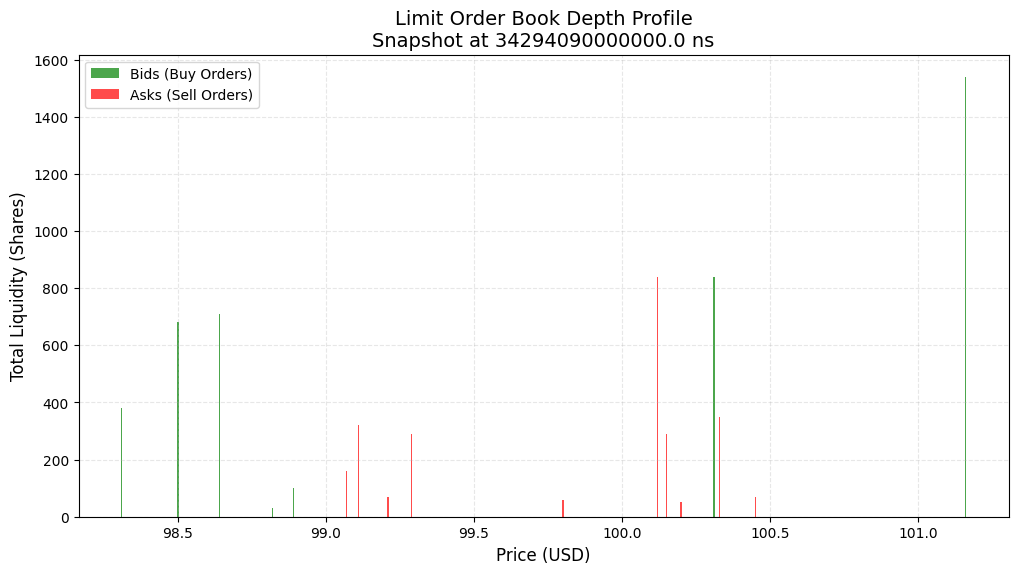

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the depth data
print("Loading LOB Depth...")
df_depth = pd.read_csv('sim_depth.csv')

# Grab a snapshot from the middle of the simulation
# Change the index [-1] to see the end, or [100] to see the start
snapshot = df_depth.iloc[len(df_depth) // 2] 

# Extract Bids (Price and Quantity), filtering out the 0.0 placeholders
bids_p = [snapshot[f'b{i}_p'] for i in range(1, 11) if snapshot[f'b{i}_p'] > 0]
bids_q = [snapshot[f'b{i}_q'] for i in range(1, 11) if snapshot[f'b{i}_p'] > 0]

# Extract Asks (Price and Quantity), filtering out the 0.0 placeholders
asks_p = [snapshot[f'a{i}_p'] for i in range(1, 11) if snapshot[f'a{i}_p'] > 0]
asks_q = [snapshot[f'a{i}_q'] for i in range(1, 11) if snapshot[f'a{i}_p'] > 0]

# 2. Plot the Order Book
plt.figure(figsize=(12, 6))

# Use a very small width for the bars so they look like ticks
bar_width = 0.005 

plt.bar(bids_p, bids_q, color='green', width=bar_width, alpha=0.7, label='Bids (Buy Orders)')
plt.bar(asks_p, asks_q, color='red', width=bar_width, alpha=0.7, label='Asks (Sell Orders)')

# Formatting
plt.title(f"Limit Order Book Depth Profile\nSnapshot at {snapshot['sim_time_ns']} ns", fontsize=14)
plt.xlabel("Price (USD)", fontsize=12)
plt.ylabel("Total Liquidity (Shares)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3, linestyle='--')

plt.show()